# Practice 13a — Optimization (선택 심화)

학습 결과는 **데이터 전처리·가중치 초기화·옵티마이저·활성화 함수·BatchNorm** 에 따라 크게 달라집니다. 각 요소를 한 번에 한 가지씩 격리해서 비교합니다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 전처리 (스케일이 다르면?) |
| 2 | 가중치 초기화 (Random vs He) |
| 3 | 옵티마이저 (SGD vs Adam) |
| 4 | 활성화 함수 (Sigmoid vs ReLU) |
| 5 | BatchNorm (없음 vs 있음) |

> 본 노트북은 선택 심화입니다. 기본 학습을 마친 후 더 깊게 알고 싶을 때 참고하세요.

Original Authors: Seungjae Ryan Lee, Ki Hyun Kim
Source: https://github.com/deeplearningzerotoall/PyTorch


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 로드 + 분할 + 표준화
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

mu = X_train.mean(0)
sigma = X_train.std(0) + 1e-8
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_s), torch.LongTensor(y_train)),
    batch_size=64, shuffle=True)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_s), torch.LongTensor(y_test)),
    batch_size=64)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}, device: {device}')


Train: 1437, Test: 360, device: cuda


In [2]:
# 학습 - epochs 만큼 학습 + 매 epoch 평가
# (train_losses, test_losses, test_accs) 반환
def train(model, train_loader, test_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_loss = loss_sum / count
        test_loss, test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
    return train_losses, test_losses, test_accs


# 평가 - (loss, accuracy) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
    return loss_sum / count, correct / count


---
# 1. 데이터 전처리 (Data Preprocessing)

특징의 스케일이 다르면 경사하강법이 지그재그로 수렴합니다.
표준화: $x_i^{\text{new}} = (x_i - \mu_i) / \sigma_i$

효과를 보기 위해 **일부 특징의 스케일을 100배로 키운** 데이터로 실험합니다.

In [3]:
# 스케일 불균형 데이터 생성: 앞 32개 특징을 20배로
X_skewed = X.copy()
X_skewed[:, :32] *= 20

Xsk_tr, Xsk_te, _, _ = train_test_split(
    X_skewed, y, test_size=0.2, random_state=42, stratify=y)

# 표준화
sk_mu = Xsk_tr.mean(0)
sk_std = Xsk_tr.std(0) + 1e-8
Xsk_tr_s = (Xsk_tr - sk_mu) / sk_std
Xsk_te_s = (Xsk_te - sk_mu) / sk_std

# DataLoader
raw_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(Xsk_tr), torch.LongTensor(y_train)),
    batch_size=64, shuffle=True)
raw_test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(Xsk_te), torch.LongTensor(y_test)),
    batch_size=64)

std_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(Xsk_tr_s), torch.LongTensor(y_train)),
    batch_size=64, shuffle=True)
std_test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(Xsk_te_s), torch.LongTensor(y_test)),
    batch_size=64)

print(f'Raw mean and std: {Xsk_tr.mean():.0f}, {Xsk_tr.std():.0f}')
print(f'Scaled mean and std: {Xsk_tr_s.mean():.0f}, {Xsk_tr_s.std():.0f}')

Raw mean and std: 52, 97
Scaled mean and std: 0, 1


Raw (skewed)  -> Test Acc: 0.639
Standardized  -> Test Acc: 0.931


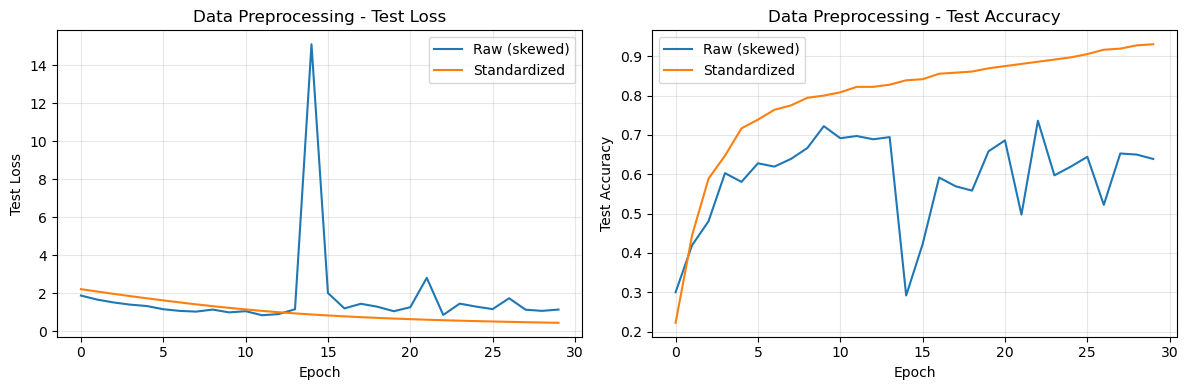

스케일이 다르면 SGD가 수렴하지 못합니다. 표준화는 필수 전처리입니다.


In [4]:
# === Raw (표준화 없음) ===
torch.manual_seed(42)
model_raw = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
optimizer_raw = torch.optim.SGD(model_raw.parameters(), lr=0.01)
tl_raw, vl_raw, va_raw = train(model_raw, raw_train_loader, raw_test_loader, optimizer_raw, epochs=30, device=device)

# === Standardized (표준화) ===
torch.manual_seed(42)
model_std = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
optimizer_std = torch.optim.SGD(model_std.parameters(), lr=0.01)
tl_std, vl_std, va_std = train(model_std, std_train_loader, std_test_loader, optimizer_std, epochs=30, device=device)

print(f'Raw (skewed)  -> Test Acc: {va_raw[-1]:.3f}')
print(f'Standardized  -> Test Acc: {va_std[-1]:.3f}')

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vl_raw, label='Raw (skewed)')
axes[0].plot(vl_std, label='Standardized')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Data Preprocessing - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(va_raw, label='Raw (skewed)')
axes[1].plot(va_std, label='Standardized')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Data Preprocessing - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('스케일이 다르면 SGD가 수렴하지 못합니다. 표준화는 필수 전처리입니다.')


---
# 2. 가중치 초기화 (Weight Initialization)

| 방법 | 설명 | 적합한 활성 함수 |
|------|------|------|
| Zero | $w = 0$ (사용 금지 — 대칭성) | - |
| He (Kaiming) | $N(0, 2/n_{in})$ | ReLU |

**8층 깊은 네트워크 + SGD**에서 초기화의 차이를 확인합니다.

Large Random init -> Test Acc: 0.850
He init           -> Test Acc: 0.950


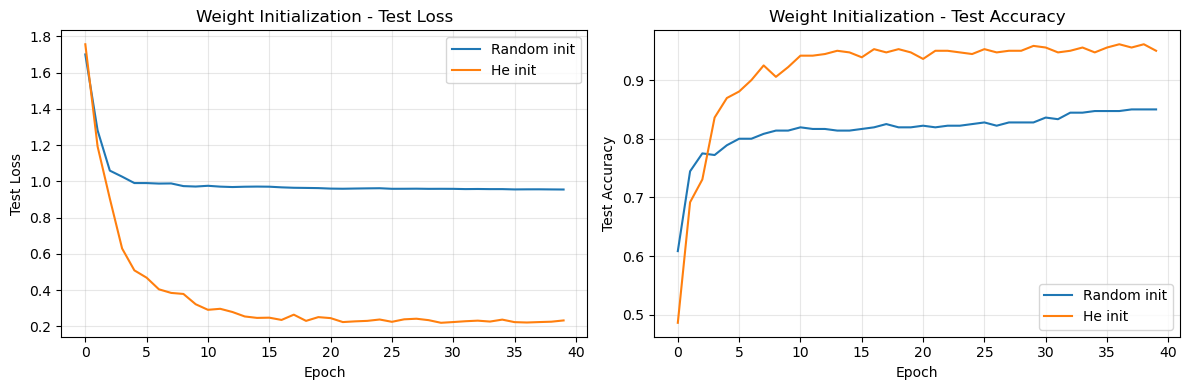

큰 Random 초기화는 학습이 되지 않습니다. He 초기화를 사용하세요.


In [5]:
# === 큰 Random 초기화 (8층) ===
torch.manual_seed(42)
model_large_random = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_large_random:
    if isinstance(layer, nn.Linear):
        nn.init.normal_(layer.weight, mean=0.0, std=0.2)
        nn.init.normal_(layer.bias, mean=0.0, std=0.2)
model_large_random = model_large_random.to(device)
optimizer_zero = torch.optim.SGD(model_large_random.parameters(), lr=0.01)
tl_zero, vl_zero, va_zero = train(model_large_random, train_loader, test_loader, optimizer_zero, epochs=40, device=device)

# === He (Kaiming) 초기화 (8층) ===
torch.manual_seed(42)
model_he = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_he:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
model_he = model_he.to(device)
optimizer_he = torch.optim.SGD(model_he.parameters(), lr=0.01)
tl_he, vl_he, va_he = train(model_he, train_loader, test_loader, optimizer_he, epochs=40, device=device)

print(f'Large Random init -> Test Acc: {va_zero[-1]:.3f}')
print(f'He init           -> Test Acc: {va_he[-1]:.3f}')

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vl_zero, label='Random init')
axes[0].plot(vl_he, label='He init')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Weight Initialization - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(va_zero, label='Random init')
axes[1].plot(va_he, label='He init')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Weight Initialization - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('큰 Random 초기화는 학습이 되지 않습니다. He 초기화를 사용하세요.')


---
# 3. 옵티마이저 비교 (Optimizer Comparison)

| 옵티마이저 | 설명 |
|---|---|
| SGD | $\theta \leftarrow \theta - \rho \nabla J$ |
| Adam | 1차 + 2차 모멘트로 적응적 학습률 |

SGD  (lr=0.01)  -> Test Acc: 0.900
Adam (lr=0.001) -> Test Acc: 0.981


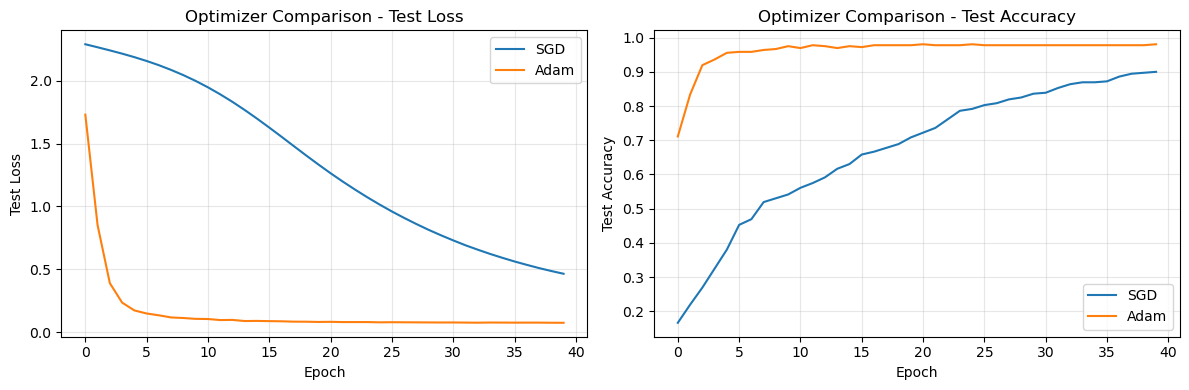

Adam은 적응적 학습률로 SGD보다 빠르게 수렴합니다.


In [6]:
# === SGD ===
torch.manual_seed(42)
model_sgd = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
).to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)
tl_sgd, vl_sgd, va_sgd = train(model_sgd, train_loader, test_loader, optimizer_sgd, epochs=40, device=device)

# === Adam ===
torch.manual_seed(42)
model_adam = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
).to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
tl_adam, vl_adam, va_adam = train(model_adam, train_loader, test_loader, optimizer_adam, epochs=40, device=device)

print(f'SGD  (lr=0.01)  -> Test Acc: {va_sgd[-1]:.3f}')
print(f'Adam (lr=0.001) -> Test Acc: {va_adam[-1]:.3f}')

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vl_sgd, label='SGD')
axes[0].plot(vl_adam, label='Adam')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Optimizer Comparison - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(va_sgd, label='SGD')
axes[1].plot(va_adam, label='Adam')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Optimizer Comparison - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Adam은 적응적 학습률로 SGD보다 빠르게 수렴합니다.')


---
# 4. 활성 함수 (Activation Functions)

Sigmoid/Tanh는 $|z|$가 커지면 gradient → 0 (**포화**).
ReLU: $\max(0, z)$ — 포화 없이 빠른 학습.

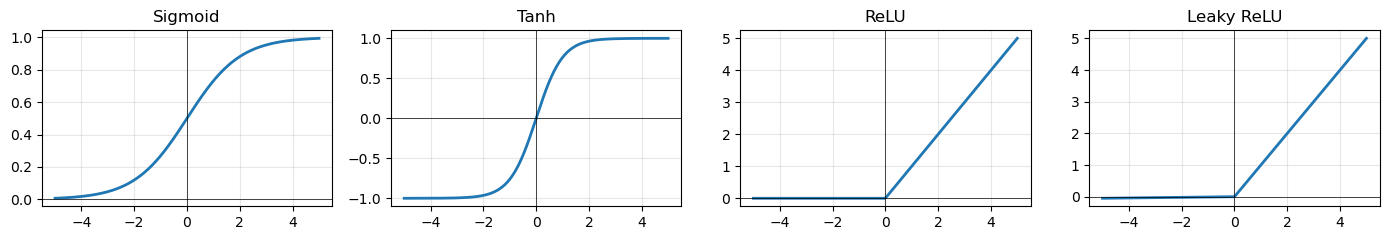

In [7]:
# 활성 함수 그래프
z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 4, figsize=(14, 2.5))

axes[0].plot(z, 1 / (1 + np.exp(-z)), linewidth=2)
axes[0].set_title('Sigmoid')

axes[1].plot(z, np.tanh(z), linewidth=2)
axes[1].set_title('Tanh')

axes[2].plot(z, np.maximum(0, z), linewidth=2)
axes[2].set_title('ReLU')

axes[3].plot(z, np.where(z > 0, z, 0.01 * z), linewidth=2)
axes[3].set_title('Leaky ReLU')

for ax in axes:
    ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

Sigmoid -> Test Acc: 0.772
ReLU    -> Test Acc: 0.975


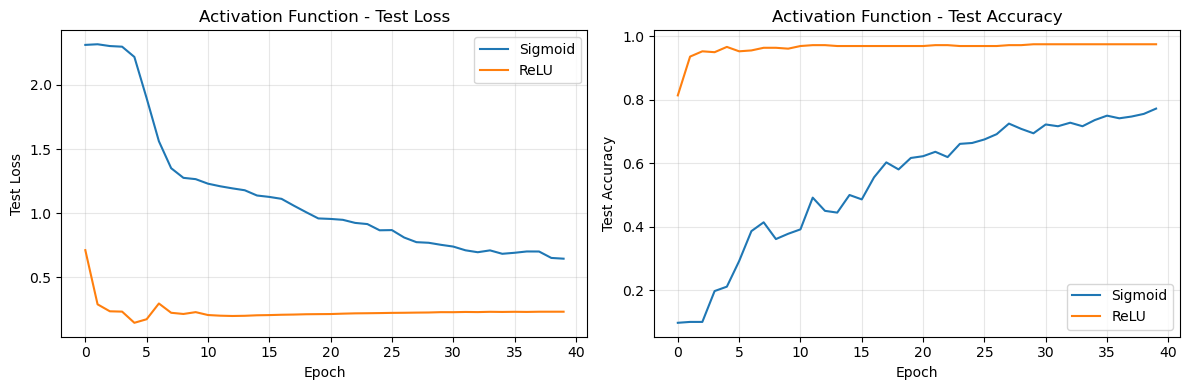

깊은 네트워크에서 Sigmoid는 gradient vanishing으로 학습이 안 됩니다.


In [8]:
# === Sigmoid (8층) ===
torch.manual_seed(42)
model_sig = nn.Sequential(
    nn.Linear(64, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 10)
)
for layer in model_sig:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
model_sig = model_sig.to(device)
optimizer_sig = torch.optim.Adam(model_sig.parameters(), lr=0.001)
tl_sig, vl_sig, va_sig = train(model_sig, train_loader, test_loader, optimizer_sig, epochs=40, device=device)

# === ReLU (8층) ===
torch.manual_seed(42)
model_relu = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_relu:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
model_relu = model_relu.to(device)
optimizer_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
tl_relu, vl_relu, va_relu = train(model_relu, train_loader, test_loader, optimizer_relu, epochs=40, device=device)

print(f'Sigmoid -> Test Acc: {va_sig[-1]:.3f}')
print(f'ReLU    -> Test Acc: {va_relu[-1]:.3f}')

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vl_sig, label='Sigmoid')
axes[0].plot(vl_relu, label='ReLU')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Activation Function - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(va_sig, label='Sigmoid')
axes[1].plot(va_relu, label='ReLU')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Activation Function - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('깊은 네트워크에서 Sigmoid는 gradient vanishing으로 학습이 안 됩니다.')


---
# 5. 배치 정규화 (Batch Normalization)

각 층 출력을 미니배치 단위로 정규화 → 학습 안정화, 더 큰 학습률 사용 가능.

$$\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad z'_i = \gamma \hat{z}_i + \beta$$

**높은 학습률(SGD lr=0.1)**에서 BatchNorm의 안정화 효과를 확인합니다.

Without BN -> Test Acc: 0.969
With BN    -> Test Acc: 0.986


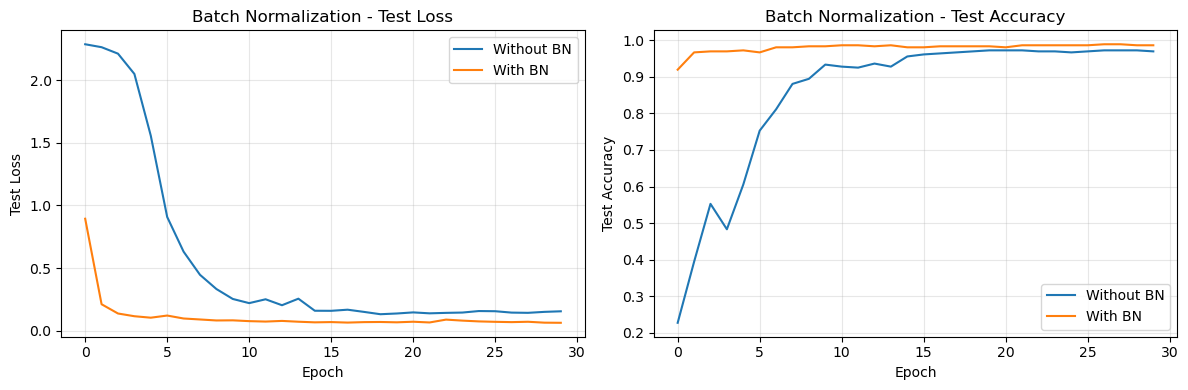

BatchNorm을 사용하면 높은 learning rate에서도 안정적으로 수렴합니다.


In [9]:
# === Without BatchNorm ===
torch.manual_seed(42)
model_no_bn = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
optimizer_no_bn = torch.optim.SGD(model_no_bn.parameters(), lr=0.1)
tl_nobn, vl_nobn, va_nobn = train(model_no_bn, train_loader, test_loader, optimizer_no_bn, epochs=30, device=device)

# === With BatchNorm ===
torch.manual_seed(42)
model_bn = nn.Sequential(
    nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
optimizer_bn = torch.optim.SGD(model_bn.parameters(), lr=0.1)
tl_bn, vl_bn, va_bn = train(model_bn, train_loader, test_loader, optimizer_bn, epochs=30, device=device)

print(f'Without BN -> Test Acc: {va_nobn[-1]:.3f}')
print(f'With BN    -> Test Acc: {va_bn[-1]:.3f}')

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vl_nobn, label='Without BN')
axes[0].plot(vl_bn, label='With BN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Batch Normalization - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(va_nobn, label='Without BN')
axes[1].plot(va_bn, label='With BN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Batch Normalization - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('BatchNorm을 사용하면 높은 learning rate에서도 안정적으로 수렴합니다.')


---
### 연습 문제

1. 옵티마이저 비교에 `SGD + Momentum 0.9`를 추가해 보세요.
2. 가중치 초기화 비교에서 `nn.init.xavier_uniform_`을 사용해 보세요.
3. (도전) 배치 정규화 실험을 lr=0.001, 0.01, 0.1에서 반복하고, BN이 큰 학습률에서 얼마나 유리한지 보여주세요.

In [10]:
# 연습 문제 풀이 공간

